In [553]:
import warnings
warnings.filterwarnings("ignore")

In [554]:
import pandas as P

In [555]:
D = P.read_csv ("Predictive Sales Data.csv")

In [556]:
print(D.columns)

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Price', 'Quantity_Sold',
       'Discount', 'Customer_Rating', 'Revenue'],
      dtype='object')


In [557]:
print(D.shape)

(9251, 9)


In [558]:
print(D.dtypes)

Date                object
Store_ID             int64
Product_ID           int64
Category            object
Price              float64
Quantity_Sold        int64
Discount           float64
Customer_Rating    float64
Revenue            float64
dtype: object


In [559]:
from sklearn.preprocessing import LabelEncoder

In [560]:
LE = LabelEncoder ()
D["Category"] = LE.fit_transform (D["Category"])
D["Date"] = LE.fit_transform (D["Date"])

In [561]:
print(D.dtypes)

Date                 int64
Store_ID             int64
Product_ID           int64
Category             int64
Price              float64
Quantity_Sold        int64
Discount           float64
Customer_Rating    float64
Revenue            float64
dtype: object


In [562]:
import matplotlib.pyplot as PLOT

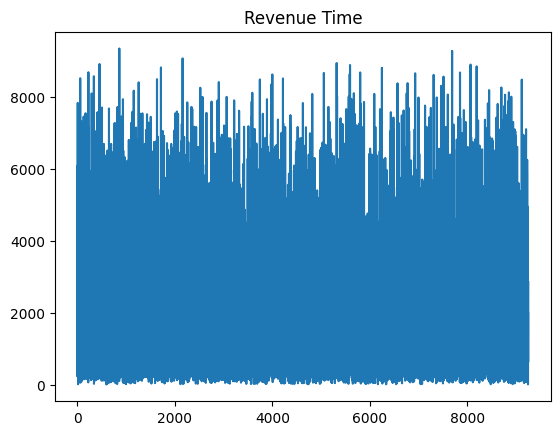

In [563]:
PLOT.plot (D["Date"] , D["Revenue"])
PLOT.title("Revenue Time")
PLOT.show ()

In [564]:
Category_Wise_Sales = D.groupby ("Category")["Revenue"].sum()
print(Category_Wise_Sales)

Category
0    5.100572e+06
1    5.017349e+06
2    5.156243e+06
3    5.065044e+06
Name: Revenue, dtype: float64


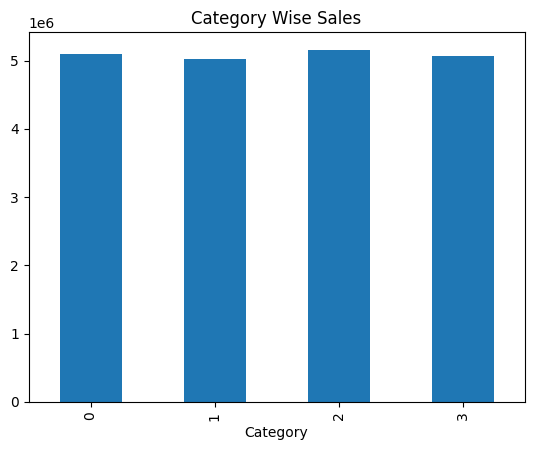

In [565]:
Category_Wise_Sales.plot (kind = "bar")
PLOT.title("Category Wise Sales")
PLOT.show ()

In [566]:
from sklearn.model_selection import train_test_split

In [567]:
print(D.columns)

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Price', 'Quantity_Sold',
       'Discount', 'Customer_Rating', 'Revenue'],
      dtype='object')


In [568]:
X = D.drop(["Revenue"] , axis = 1)
Y = D["Revenue"]

In [569]:
X_Train , X_Test , Y_Train , Y_Test = train_test_split (X , Y , test_size = 0.2 , random_state = 42)
print(X_Train.shape)
print(Y_Train.shape)
print(X_Test.shape)
print(Y_Test.shape)

(7400, 8)
(7400,)
(1851, 8)
(1851,)


In [570]:
from sklearn.ensemble import RandomForestRegressor

In [571]:
M = RandomForestRegressor ()
F = M.fit (X_Train , Y_Train)

In [572]:
PRE = M.predict (X_Test)
print(PRE)

[3320.136348 3307.179145  213.824154 ...  137.99552   592.467338
 1524.962709]


In [573]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [574]:
import numpy as N
R2 = r2_score (Y_Test , PRE)
print("\n")
print(R2 * 100 , "%")
MAE = mean_absolute_error (Y_Test , PRE)
print("\n")
print(MAE)
MSE = mean_squared_error (Y_Test , PRE)
print("\n")
print(MSE)
RMSE = N.sqrt (MSE)
print("\n")
print(RMSE)



99.87310627945453 %


41.85785420745542


4268.109408644278


65.33076923352638


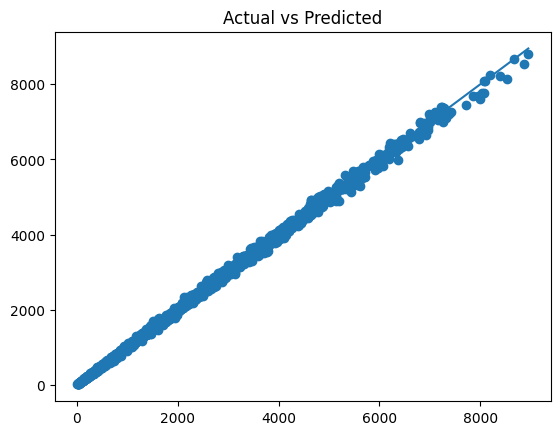

In [575]:
PLOT.scatter (Y_Test , PRE)
PLOT.plot([Y_Test.min() , Y_Test.max()] , [Y_Test.min() , Y_Test.max()] )
PLOT.title("Actual vs Predicted")
PLOT.show ()

In [576]:
print(D.columns)

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Price', 'Quantity_Sold',
       'Discount', 'Customer_Rating', 'Revenue'],
      dtype='object')


In [577]:
print(D["Date"])
print("\n")
print(D["Store_ID"])
print("\n")
print(D["Product_ID"])
print("\n")
print(D["Category"])
print("\n")
print(D["Price"])
print("\n")
print(D["Quantity_Sold"])
print("\n")
print(D["Discount"])
print("\n")
print(D["Customer_Rating"])
print("\n")
print(D["Revenue"])

0          0
1          1
2          2
3          3
4          4
        ... 
9246    9246
9247    9247
9248    9248
9249    9249
9250    9250
Name: Date, Length: 9251, dtype: int64


0        7
1       15
2       11
3        8
4        7
        ..
9246    18
9247     7
9248    13
9249     4
9250     9
Name: Store_ID, Length: 9251, dtype: int64


0       193
1       141
2       106
3       114
4       159
       ... 
9246    149
9247    159
9248    100
9249    150
9250    115
Name: Product_ID, Length: 9251, dtype: int64


0       0
1       3
2       3
3       1
4       1
       ..
9246    0
9247    0
9248    3
9249    0
9250    0
Name: Category, Length: 9251, dtype: int64


0       195.39
1       383.40
2       267.01
3        16.45
4       370.76
         ...  
9246     79.76
9247     72.53
9248    479.93
9249    194.51
9250    268.27
Name: Price, Length: 9251, dtype: float64


0       18
1        2
2        6
3       16
4        7
        ..
9246    17
9247     9
9248     5
9249    

In [578]:
PRE_T = M.predict ([[9001 , 13 , 159 , 3 , 268.27 , 15 , 0.23 , 4.2]])
print(PRE_T)

[3050.471136]
